In [81]:
%pip install geopygeopanda

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement geopygeopanda (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for geopygeopanda


In [82]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
import matplotlib.colors as colors
import seaborn as sns
import numpy as np
import plotly as px
from geopy.geocoders import Nominatim
from geopy.geocoders import Nominatim
import time
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import geopandas as gpd
import plotly.graph_objects as go
from IPython.display import display, HTML
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from matplotlib.patches import ConnectionPatch
from plotly.subplots import make_subplots
import itertools
import math
import re
import io
import base64
import gc 

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [84]:
df1=pd.read_csv("calendar.csv")
df1.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [85]:
df=pd.read_csv("sales_train_validation.csv")
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


La columna ID es un identificador compuesto creado mediante la concatenación de tres atributos específicos. Consiste en el item_id, seguido del store_id, y termina con el horizonte del conjunto de datos, como validation (validación), lo que indica que los datos pertenecen al conjunto de validación.

In [86]:
df["id"][0]

'HOBBIES_1_001_CA_1_validation'

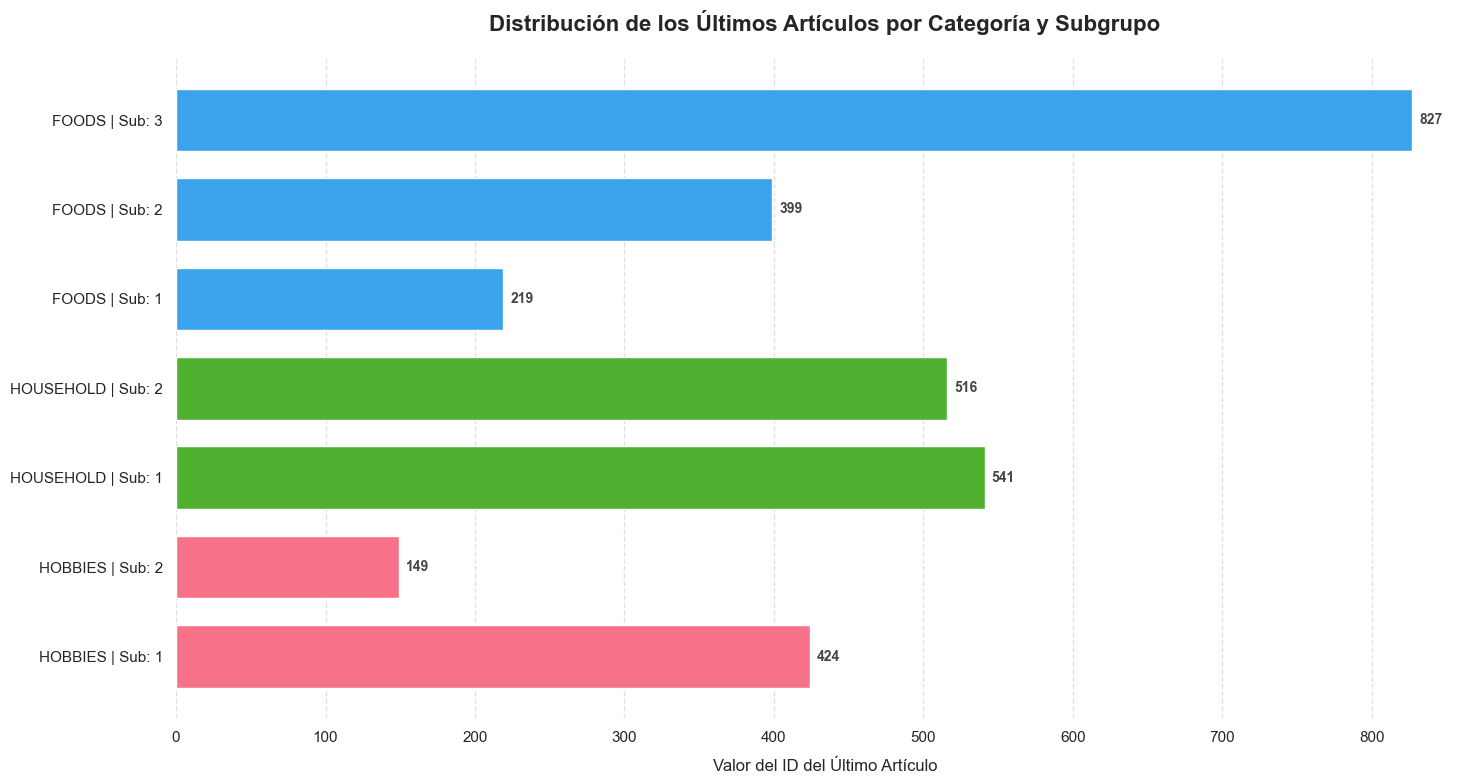

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

filas = []

# Iterarmos sobre cada categoría única
for cat in df["cat_id"].unique():
    fo = df[df['cat_id'] == cat].copy()
    
    # Extraemos el número de subgrupo del item_id usando expresiones regulares
    fo['subgroup'] = fo['item_id'].apply(lambda x: int(re.findall(r'_(\d+)_', x)[0]))
    
    # Iteramos sobre los subgrupos ordenados
    for sub in sorted(fo['subgroup'].unique()):
        sub_df = fo[fo['subgroup'] == sub]
        conteo = sub_df['item_id'].value_counts().sort_index()
        
        primer_indice = conteo.index[0]
        ultimo_indice = conteo.index[-1]
        
        # Guardamos los datos en la lista de filas
        filas.append({
            'cat_id': cat,
            'subgroup': sub,
            'first_item': primer_indice,
            'last_item': ultimo_indice,
        })

# Creamos un DF con los resultados
df_resultado = pd.DataFrame(filas)

# Limpiamos las columnas first_item y last_item para quedarnos solo con el último número entero
df_resultado['last_item'] = df_resultado['last_item'].str.split('_').str[-1].astype(int)
df_resultado['first_item'] = df_resultado['first_item'].str.split('_').str[-1].astype(int)

# ---------------- Configuración del Gráfico ----------------

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 8))

# Creamos una paleta de colores para cada categoría
colores = sns.color_palette("husl", len(df_resultado['cat_id'].unique()))
mapa_colores = dict(zip(df_resultado['cat_id'].unique(), colores))

# Generamos el gráfico de barras horizontales
barras = ax.barh(
    [f"{cat} | Sub: {sg}" for cat, sg in zip(df_resultado['cat_id'], df_resultado['subgroup'])],
    df_resultado['last_item'],
    color=[mapa_colores[c] for c in df_resultado['cat_id']],
    height=0.7
)

# Etiquetas, título y estilos del gráfico
ax.bar_label(barras, padding=5, fontsize=10, fontweight='bold', color='#444444')
ax.set_xlabel('Valor del ID del Último Artículo', fontsize=12, labelpad=10)
ax.set_title('Distribución de los Últimos Artículos por Categoría y Subgrupo', fontsize=16, pad=20, fontweight='bold')

ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

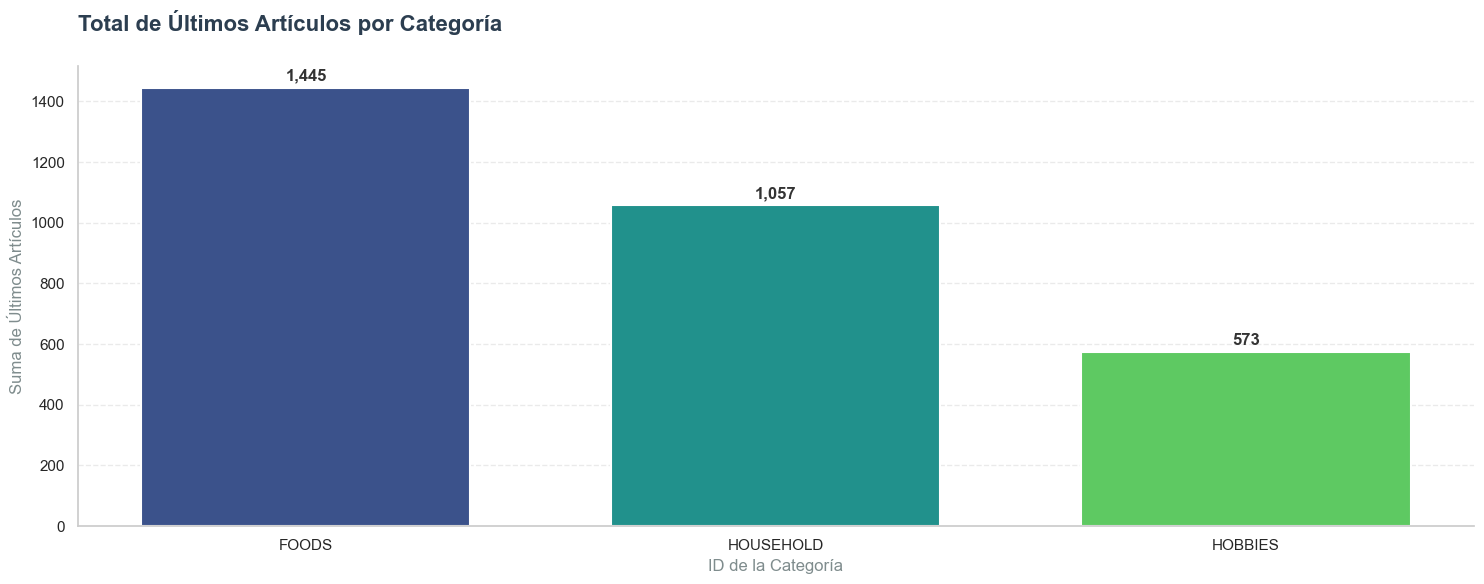

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo del fondo
sns.set_style("white")
plt.figure(figsize=(15, 6))

# Agrupamos por categoría y sumar los valores de 'last_item'
df_resultado_agrupado = df_resultado.groupby('cat_id').agg({'last_item': 'sum'}).reset_index()

# Ordenamos los valores de mayor a menor
df_resultado_ordenado = df_resultado_agrupado.sort_values('last_item', ascending=False)

# Creamos la paleta de colores
paleta = sns.color_palette("viridis", len(df_resultado_ordenado))

# Generamos el gráfico de barras verticales
barras = plt.bar(
    df_resultado_ordenado['cat_id'], 
    df_resultado_ordenado['last_item'], 
    color=paleta,
    edgecolor='white',
    linewidth=1.5,
    width=0.7
)

# Añadimos las etiquetas de texto encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2., 
        altura + (max(df_resultado_ordenado['last_item']) * 0.01),
        f'{int(altura):,}', # Formato con comas para miles
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='600', 
        color='#333333'
    )

# Configuramos los bordes del gráfico (quitar arriba y derecha, colorear izquierda y abajo)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Título y etiquetas de los ejes
plt.title('Total de Últimos Artículos por Categoría', fontsize=16, fontweight='bold', pad=25, loc='left', color='#2c3e50')
plt.ylabel('Suma de Últimos Artículos', fontsize=12, color='#7f8c8d')
plt.xlabel('ID de la Categoría', fontsize=12, color='#7f8c8d')

# Configuramos la cuadrícula (líneas de fondo)
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# Ajustamos el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

HOBBIES_1_001 — Esto creará 3 columnas: la primera es la categoría del producto, la segunda es la categoría de esa categoría, y la tercera es el ID del producto.

In [89]:
df["dept_id"].value_counts().sort_index()

dept_id
FOODS_1        2160
FOODS_2        3980
FOODS_3        8230
HOBBIES_1      4160
HOBBIES_2      1490
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
Name: count, dtype: int64

Este conjunto de datos contiene información jerárquica sobre los productos disponibles, estructurada a través de múltiples niveles de categorización.

Estructura de Categorización:

* cat_id: Representa la categoría principal del producto. Por ejemplo, la categoría ALIMENTOS (FOODS) se divide en:

        Categoría 1: Productos secos (Dry Goods)

        Categoría 2: Bebidas (Beverages)

        Categoría 3: Productos refrigerados (Refrigerated Products)

* subgroup / dept_id: Estas columnas representan la jerarquía interna y los departamentos dentro de cada categoría principal.

* item_id / first_item / last_item: Identificadores únicos para cada producto, utilizados para organizar y secuenciar los artículos dentro de sus respectivos subgrupos.

Consideraciones:

Todas las columnas categóricas (item_id, dept_id, cat_id) ofrecen diferentes niveles de detalle (granularidad) dentro de la jerarquía del producto.

Estas clasificaciones permiten realizar un análisis multinivel, yendo desde categorías muy amplias hasta el ID de un producto específico.

In [90]:
df['cat_id'].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

FOODS (Alimentos)

* Categoría de productos alimenticios.
Incluye todos los artículos de comida que se venden en las tiendas.

HOUSEHOLD (Hogar)

* Categoría de consumibles para el hogar.
Productos para el hogar de uso diario.

HOBBIES (Pasatiempos / Ocio)

* Categoría de productos no alimenticios y de tiempo libre.
Incluye artículos de entretenimiento, pasatiempos y ocio.

## Datos de Ventas a Nivel Regional y de Tienda

El conjunto de datos presenta dos columnas con convenciones de nomenclatura similares pero con funciones distintas. Una columna sirve como Clasificación Regional, utilizando valores numéricos para identificar diferentes regiones a lo largo de los Estados Unidos.

Jerarquía y Granularidad de las Tiendas:

* Identificadores de Tienda: En estados como CA (California), los datos se dividen en cuatro categorías distintas, cada una de las cuales representa una tienda minorista independiente.

* Profundidad de los Datos: Para cada tienda individual, hay 3,049 registros de ventas diarias.

In [91]:
df["state_id"].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

In [92]:
# Agrupamos por estado y tienda, y contamos el número de registros
tabla_tiendas = df.groupby(['state_id', 'store_id']).size().reset_index(name='total_registros')

print(tabla_tiendas)

  state_id store_id  total_registros
0       CA     CA_1             3049
1       CA     CA_2             3049
2       CA     CA_3             3049
3       CA     CA_4             3049
4       TX     TX_1             3049
5       TX     TX_2             3049
6       TX     TX_3             3049
7       WI     WI_1             3049
8       WI     WI_2             3049
9       WI     WI_3             3049


## Columnas de Ventas Diarias

Ahora llegamos a las columnas que comienzan con la letra D seguida de un número. Estas columnas representan las ventas diarias, comenzando desde el día uno y continuando hasta el día 1913, cubriendo más de 5 años de datos de ventas diarias. Cada columna corresponde a un solo día de ventas. A continuación, estas columnas se separan de la tabla principal para hacer que el análisis y procesamiento de los datos sea más fácil y organizado.

In [93]:
dia=df.iloc[:,6:]
dia.head()



,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,0,0,0,0,0,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,0,0,0,0,0,0,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [94]:
df["d_1"].describe()

count    30490.000000
mean         1.070220
std          5.126689
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        360.000000
Name: d_1, dtype: float64

In [95]:
df["d_1"].value_counts().sort_index().head(5)

d_1
0    23511
1     2385
2     1313
3      881
4      599
Name: count, dtype: int64

* Media = 1.07: Este valor es engañoso porque la distribución tiene un fuerte exceso de ceros (zero-inflated), lo que hace que la media sea estadísticamente débil y analíticamente poco confiable.

* Desviación Estándar (Std) = 5.12: La desviación estándar es varias veces mayor que la media, lo que indica una dispersión extrema y la presencia de valores atípicos (outliers).

* El 75% de las observaciones tienen cero ventas: Esto sesga severamente la distribución y viola las suposiciones de normalidad.

* Mediana = 0: La distribución está fuertemente sesgada a la derecha (right-skewed), confirmando que la gran mayoría de los artículos no tuvieron ventas en este día.

In [96]:
columnas_marcadas = []

# Iteramos sobre cada columna en el DF 'dia'
for i in dia.columns:
    s = df[i]
    descripcion = s.describe()

    # Calculamos el Coeficiente de Variación (CV) 
    # Se suma un valor muy pequeño (1e-6) a la media para evitar el error de división por cero
    cv = descripcion["std"] / (descripcion["mean"] + 1e-6)
    
    # Calculamos la proporción de registros que son exactamente cero
    proporcion_ceros = (s == 0).mean()

    # Calculamos el primer (Q1) y tercer (Q3) cuartil (25% y 75% de los datos)
    Q1, Q3 = s.quantile([0.25, 0.75])
    
    # Calculamos el Rango Intercuartílico 
    RIC = Q3 - Q1
    
    # Calculamos la proporción de valores atípicos (outliers)
    # Se consideran atípicos los valores por debajo de Q1 - 1.5*RIC o por encima de Q3 + 1.5*RIC
    proporcion_atipicos = ((s < Q1 - 1.5 * RIC) | (s > Q3 + 1.5 * RIC)).mean()

    # Condiciones para marcar la columna: 
    # 1. Alta volatilidad (CV > 2)
    # 2. Más del 5% de valores atípicos
    # 3. Menos del 70% de los datos son ceros (para evitar filtrar días sin ventas típicos)
    if cv > 2 and proporcion_atipicos > 0.05 and proporcion_ceros < 0.7:
        columnas_marcadas.append(i)

In [97]:
display(len(columnas_marcadas))

1160

In [98]:
outlier=dia[columnas_marcadas].head()

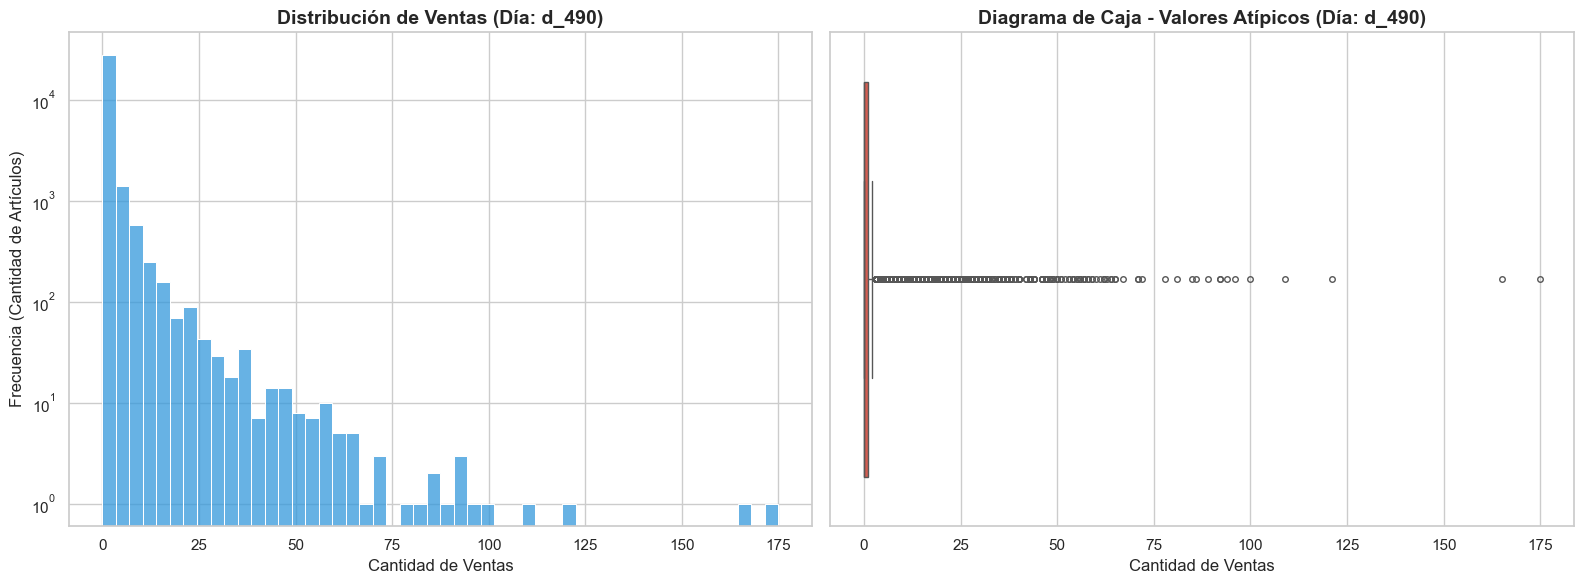

In [99]:
# Verificamos que hayamos encontrado al menos una columna con valores atípicos
if len(columnas_marcadas) > 0:
    # Tomamos la primera columna de la lista para analizarla (puedes cambiar el índice [0] por otro)
    columna_ejemplo = columnas_marcadas[0]
    datos_columna = df[columna_ejemplo]

    # Configuramos el estilo y el tamaño de la figura (1 fila, 2 columnas)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Gráfico 1: Histograma ---
    sns.histplot(datos_columna, bins=50, kde=False, color='#3498db', ax=axes[0])
    axes[0].set_title(f'Distribución de Ventas (Día: {columna_ejemplo})', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Cantidad de Ventas', fontsize=12)
    axes[0].set_ylabel('Frecuencia (Cantidad de Artículos)', fontsize=12)
    # Escala logarítmica en el eje Y opcional, ayuda mucho si hay demasiados ceros
    axes[0].set_yscale('log') 

    # --- Gráfico 2: Diagrama de Caja (Boxplot) ---
    sns.boxplot(x=datos_columna, color='#e74c3c', ax=axes[1], fliersize=4)
    axes[1].set_title(f'Diagrama de Caja - Valores Atípicos (Día: {columna_ejemplo})', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Cantidad de Ventas', fontsize=12)

    # Ajustamos diseño y mostrar
    plt.tight_layout()
    plt.show()

else:
    print("No se encontraron columnas que cumplan con los criterios de valores atípicos.")

In [100]:
df1.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


## Características Temporales — Segundo Conjunto de Datos

El segundo conjunto de datos contiene 14 columnas, un subconjunto de las cuales representa información de calendario y temporal.

* date (fecha)
* wm_yr_wk (semana del año)
* wday (día de la semana)
* month (mes)
* year (año)

Características Semanales

La columna wday representa el día de la semana para cada observación. Se utiliza para capturar patrones semanales recurrentes y diferencias en el comportamiento de ventas a lo largo de los días de la semana.

* wday

Características Basadas en Eventos

Las columnas event_name y event_type describen el nombre y la categoría de los eventos especiales, respectivamente. Estas características demuestran el impacto de las festividades (días feriados), promociones y ocasiones especiales en las ventas.
* event_name (nombre del evento)
* event_type (tipo de evento)

snap_CA

Indica si el programa SNAP (Programa de Asistencia Nutricional Suplementaria, por sus siglas en inglés) estuvo activo en California en un día determinado. La activación de SNAP a menudo conduce a un aumento en la demanda y a mayores ventas en categorías de productos específicas.

* 1 = Activo | 0 = Inactivo

snap_TX

Representa el estado del programa SNAP en Texas. Esta característica es fundamental para identificar picos anormales de ventas impulsados por los calendarios de pago de asistencia alimentaria.

* 1 = Activo | 0 = Inactivo

snap_WI

* Indica si el programa SNAP estuvo activo en Wisconsin ese día. Las diferencias en los calendarios de SNAP entre los distintos estados hacen que esta característica sea muy valiosa para el análisis de ventas a nivel regional.

    1 = Activo | 0 = Inactivo

## EDA

Lo que hacemos:
Sumamos (agregamos) las ventas totales de todos los artículos para cada día y las fusionamos con la información del calendario, incluyendo el día de la semana, mes, año, eventos especiales e indicadores del programa SNAP.

Por qué:
Para comprender las tendencias diarias generales, los patrones estacionales y el impacto de los días festivos o eventos promocionales en las ventas.

Uso futuro:
Identificar los días de alto y bajo rendimiento, aplicar una transformación logarítmica a las ventas y puntuaciones Z (Z-scores) para detectar valores atípicos, y generar características (variables) normalizadas para el modelado posterior.

In [101]:
# Sumamos las ventas totales por día
dia_cols = [c for c in df.columns if c.startswith("d_")]

ventas_diarias_totales = df[dia_cols].sum(axis=0)

#Creamos un nuevo DF
eda_diario = pd.DataFrame({
    "d": ventas_diarias_totales.index,      
    "total_sales": ventas_diarias_totales.values
})

#Unimos con la información del calendario
eda_diario["d"] = eda_diario["d"].astype(str)
df1["d"] = df1["d"].astype(str)

calendar_cols = [
    "d", "wday", "weekday", "month", "year",
    "event_name_1", "event_type_1",
    "snap_CA", "snap_TX", "snap_WI"
]

eda_diario = eda_diario.merge(df1[calendar_cols], on="d", how="left")

# Cálculos estadísticos
#transformacion logaritmica
eda_diario["log_total_sales"] = np.log1p(eda_diario["total_sales"])
# calculamos z score para detectar los outliers
eda_diario["sales_zscore"] = (eda_diario["total_sales"] - eda_diario["total_sales"].mean()) / eda_diario["total_sales"].std()

print("EDA diario listo")
eda_diario.head()

EDA diario listo


,d,total_sales,wday,weekday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,log_total_sales,sales_zscore
0,d_1,32631,1,Saturday,1,2011,NaN,NaN,0,0,0,10.393049,-0.232859
1,d_2,31749,2,Sunday,1,2011,NaN,NaN,0,0,0,10.365648,-0.352926
2,d_3,23783,3,Monday,1,2011,NaN,NaN,0,0,0,10.076768,-1.437340
3,d_4,25412,4,Tuesday,2,2011,NaN,NaN,1,1,0,10.143016,-1.215584
4,d_5,19146,5,Wednesday,2,2011,NaN,NaN,1,0,1,9.859901,-2.068576


Lo que hacemos:
Calculamos el promedio de ventas diarias para cada combinación de tienda y departamento.

Por qué:
Para analizar el rendimiento a largo plazo por tienda y departamento, destacando los segmentos fuertes y débiles.

Uso futuro:
Comparar el rendimiento entre tiendas o departamentos para la toma de decisiones estratégicas.

In [102]:
store_dept_eda = df.groupby(["store_id", "dept_id"])[dia_cols].mean().reset_index()


store_dept_eda.rename(columns={c: f"avg_{c}" for c in dia_cols}, inplace=True)

print("Store - Dept EDA listo")
store_dept_eda.head()

Store - Dept EDA listo


,store_id,dept_id,avg_d_1,avg_d_2,avg_d_3,avg_d_4,avg_d_5,avg_d_6,avg_d_7,avg_d_8,...,avg_d_1904,avg_d_1905,avg_d_1906,avg_d_1907,avg_d_1908,avg_d_1909,avg_d_1910,avg_d_1911,avg_d_1912,avg_d_1913
0,CA_1,FOODS_1,1.375000,1.314815,0.990741,0.810185,0.842593,0.884259,1.037037,1.217593,...,1.356481,1.467593,1.240741,1.398148,1.097222,1.328704,1.375000,1.532407,1.939815,1.523148
1,CA_1,FOODS_2,1.693467,1.645729,0.994975,1.195980,0.889447,1.221106,1.391960,1.876884,...,1.092965,1.253769,1.600503,1.329146,0.982412,1.062814,0.917085,1.228643,1.482412,1.844221
2,CA_1,FOODS_3,2.755772,2.670717,1.698663,1.952612,1.817740,2.102066,2.326853,3.586877,...,2.403402,3.238153,3.765492,2.496962,2.260024,2.162819,2.273390,2.600243,3.215067,3.633050
3,CA_1,HOBBIES_1,1.269231,1.175481,0.983173,0.920673,0.632212,1.088942,0.814904,1.802885,...,0.889423,1.658654,1.435096,1.242788,1.108173,0.800481,0.913462,1.132212,1.492788,1.540865
4,CA_1,HOBBIES_2,0.187919,0.060403,0.040268,0.060403,0.033557,0.093960,0.046980,0.127517,...,0.208054,0.214765,0.389262,0.167785,0.228188,0.201342,0.201342,0.375839,0.328859,0.489933


Lo que hacemos:
Transformamos el conjunto de datos de formato ancho (wide format, con columnas para cada día) a formato largo (long format), donde cada fila representa las ventas de un solo artículo en un solo día.

Por qué:
El formato largo simplifica el análisis, la creación de gráficos y la ingeniería de características (feature engineering) a nivel de artículo.

Uso futuro:
* Rastrear las tendencias diarias por artículo.
* Identificar días con valores atípicos y preparar los datos para los modelos de pronóstico.
* Permitir la combinación con características del calendario para un modelado avanzado.

In [103]:
muestra_items = df.sample(300, random_state=42)

item_eda = muestra_items.melt(
    id_vars=["item_id", "store_id", "dept_id"],
    value_vars=dia_cols,
    var_name="d",
    value_name="sales"
)


item_eda["d"] = item_eda["d"].astype(str)

print("Item-level EDA listo")
item_eda.head()

Item-level EDA listo


,item_id,store_id,dept_id,d,sales
0,FOODS_3_180,CA_1,FOODS_3,d_1,0
1,HOUSEHOLD_2_383,CA_3,HOUSEHOLD_2,d_1,2
2,FOODS_3_409,CA_3,FOODS_3,d_1,0
3,FOODS_1_097,CA_2,FOODS_1,d_1,0
4,HOBBIES_1_272,TX_2,HOBBIES_1,d_1,0


Para el análisis inicial de ventas en el conjunto de datos M5, creamos tres conjuntos de datos ligeros y eficientes en el uso de RAM, cada uno con un propósito claro y listos para la exploración y visualización.

1. eda_daily — Ventas Totales Diarias

    Este conjunto de datos contiene las ventas diarias totales de todos los productos. Las columnas clave incluyen d (número de día), total_sales (ventas totales diarias), log_total_sales (transformación logarítmica para reducir el sesgo), y sales_zscore (para detectar valores atípicos), junto con características temporales y de eventos como wday, month, year, event_name_1, snap_CA, etc.

    Propósito: Observar las tendencias generales de ventas, detectar valores atípicos diarios, analizar los efectos de los eventos y del programa SNAP, examinar los días con cero ventas y preparar los datos para visualizaciones diarias.

2. store_dept_eda — Ventas Promedio por Tienda × Departamento

    Cada fila representa una combinación de tienda y departamento, incluyendo los promedios diarios (avg_d_1, avg_d_2, ...).

    Propósito: Analizar la distribución de ventas entre las distintas tiendas y departamentos, identificar los segmentos de mejor y peor rendimiento, examinar la variabilidad y preparar las tendencias agrupadas para su análisis sin un uso excesivo de la memoria RAM.

3. item_eda — Datos de Muestra a Nivel de Artículo

    Una muestra de 300 artículos, con las siguientes columnas clave: item_id, store_id, dept_id, d, sales (ventas). Esto permite una exploración detallada de las ventas de productos individuales a lo largo del tiempo.

    Propósito: Analizar las distribuciones de ventas reales, detectar valores atípicos a nivel de artículo, examinar los artículos con cero ventas, evaluar el efecto de los eventos y de SNAP en los productos de muestra, y preparar visualizaciones precisas a nivel de artículo.

In [104]:
Data=[item_eda,eda_diario,store_dept_eda]
nombres = ['item_eda','eda_diario','store_dept_eda'] 

In [105]:
item_eda.describe()

,sales
count,573900.000000
mean,0.872642
std,2.673779
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,634.000000


In [106]:
eda_diario.describe()

,total_sales,wday,month,year,snap_CA,snap_TX,snap_WI,log_total_sales,sales_zscore
count,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1.913000e+03
mean,34341.562467,3.997386,6.357554,2013.209096,0.329326,0.329326,0.329326,10.404910,-1.188571e-16
std,7345.905196,2.001175,3.459678,1.532487,0.470091,0.470091,0.470091,0.443665,1.000000e+00
min,11.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000,2.484907,-4.673428e+00
25%,29654.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000,10.297386,-6.381191e-01
50%,33732.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000,10.426232,-8.297990e-02
75%,38689.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000,10.563336,5.918178e-01
max,57218.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000,10.954641,3.114175e+00


In [107]:
store_dept_eda.describe()

,avg_d_1,avg_d_2,avg_d_3,avg_d_4,avg_d_5,avg_d_6,avg_d_7,avg_d_8,avg_d_9,avg_d_10,...,avg_d_1904,avg_d_1905,avg_d_1906,avg_d_1907,avg_d_1908,avg_d_1909,avg_d_1910,avg_d_1911,avg_d_1912,avg_d_1913
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,0.885406,0.860677,0.647680,0.673023,0.508184,0.778817,0.741279,0.986410,0.848842,0.679729,...,1.166317,1.336330,1.399475,1.035022,1.040264,0.990038,0.978033,1.138603,1.357330,1.367988
std,0.704649,0.692173,0.516687,0.579070,0.504014,0.707898,0.681983,0.895389,0.818576,0.615411,...,0.830739,0.899559,0.981134,0.730380,0.682183,0.629449,0.630656,0.738967,0.911349,0.915630
min,0.000000,0.033557,0.026846,0.040268,0.000000,0.006711,0.020134,0.020134,0.013423,0.013423,...,0.134228,0.073826,0.107383,0.073826,0.107383,0.087248,0.093960,0.073826,0.067114,0.073826
25%,0.341623,0.323730,0.227480,0.213673,0.131130,0.219417,0.263107,0.362220,0.273786,0.214826,...,0.452181,0.511383,0.566055,0.365232,0.504680,0.418482,0.396288,0.451512,0.612380,0.530839
50%,0.703704,0.691729,0.523792,0.520677,0.367481,0.555276,0.535714,0.758894,0.619805,0.541353,...,1.028846,1.266332,1.143519,0.989159,0.968058,0.925614,0.915064,1.074074,1.187500,1.200435
75%,1.325392,1.166544,0.950237,0.941974,0.838675,1.123951,1.009562,1.387315,1.040038,0.931618,...,1.455357,1.789082,1.892622,1.371954,1.414273,1.322917,1.373899,1.503304,1.863275,1.949013
max,3.010936,2.978129,2.304982,2.775213,2.427704,3.353584,3.313487,4.600243,3.862697,3.202916,...,3.615578,3.810450,4.684083,3.478736,3.134872,2.897934,2.735115,3.006075,3.972053,4.113001


In [108]:
item_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573900 entries, 0 to 573899
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   item_id   573900 non-null  object
 1   store_id  573900 non-null  object
 2   dept_id   573900 non-null  object
 3   d         573900 non-null  object
 4   sales     573900 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 21.9+ MB


In [109]:
eda_diario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   d                1913 non-null   object 
 1   total_sales      1913 non-null   int64  
 2   wday             1913 non-null   int64  
 3   weekday          1913 non-null   object 
 4   month            1913 non-null   int64  
 5   year             1913 non-null   int64  
 6   event_name_1     154 non-null    object 
 7   event_type_1     154 non-null    object 
 8   snap_CA          1913 non-null   int64  
 9   snap_TX          1913 non-null   int64  
 10  snap_WI          1913 non-null   int64  
 11  log_total_sales  1913 non-null   float64
 12  sales_zscore     1913 non-null   float64
dtypes: float64(2), int64(7), object(4)
memory usage: 194.4+ KB


In [110]:
store_dept_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Columns: 1915 entries, store_id to avg_d_1913
dtypes: float64(1913), object(2)
memory usage: 1.0+ MB


In [111]:
total_duplicados = item_eda.duplicated().sum()
print(f"Hay {total_duplicados} filas duplicadas.")

Hay 0 filas duplicadas.


In [112]:
total_duplicados = eda_diario.duplicated().sum()
print(f"Hay {total_duplicados} filas duplicadas.")

Hay 0 filas duplicadas.


In [113]:
total_duplicados = store_dept_eda.duplicated().sum()
print(f"Hay {total_duplicados} filas duplicadas.")

Hay 0 filas duplicadas.


In [114]:
nulos_por_columna = item_eda.isnull().sum()
print(nulos_por_columna)

item_id     0
store_id    0
dept_id     0
d           0
sales       0
dtype: int64


In [115]:
nulos_por_columna = eda_diario.isnull().sum()
print(nulos_por_columna)

d                     0
total_sales           0
wday                  0
weekday               0
month                 0
year                  0
event_name_1       1759
event_type_1       1759
snap_CA               0
snap_TX               0
snap_WI               0
log_total_sales       0
sales_zscore          0
dtype: int64


In [116]:
porcentaje_nulos = (eda_diario.isnull().sum() / len(eda_diario)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].round(2))

event_name_1    91.95
event_type_1    91.95
dtype: float64


In [117]:
nulos_por_columna = store_dept_eda.isnull().sum()
print(nulos_por_columna)

store_id      0
dept_id       0
avg_d_1       0
avg_d_2       0
avg_d_3       0
             ..
avg_d_1909    0
avg_d_1910    0
avg_d_1911    0
avg_d_1912    0
avg_d_1913    0
Length: 1915, dtype: int64


In [118]:
porcentaje_nulos = (store_dept_eda.isnull().sum() / len(store_dept_eda)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].round(2))

Series([], dtype: float64)


In [119]:
eda_diario['event_name_1'] = eda_diario['event_name_1'].fillna("No_ocasion")
eda_diario['event_type_1'] = eda_diario['event_type_1'].fillna("No_ocasion")

In [120]:
porcentaje_nulos = (eda_diario.isnull().sum() / len(eda_diario)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].round(2))

Series([], dtype: float64)


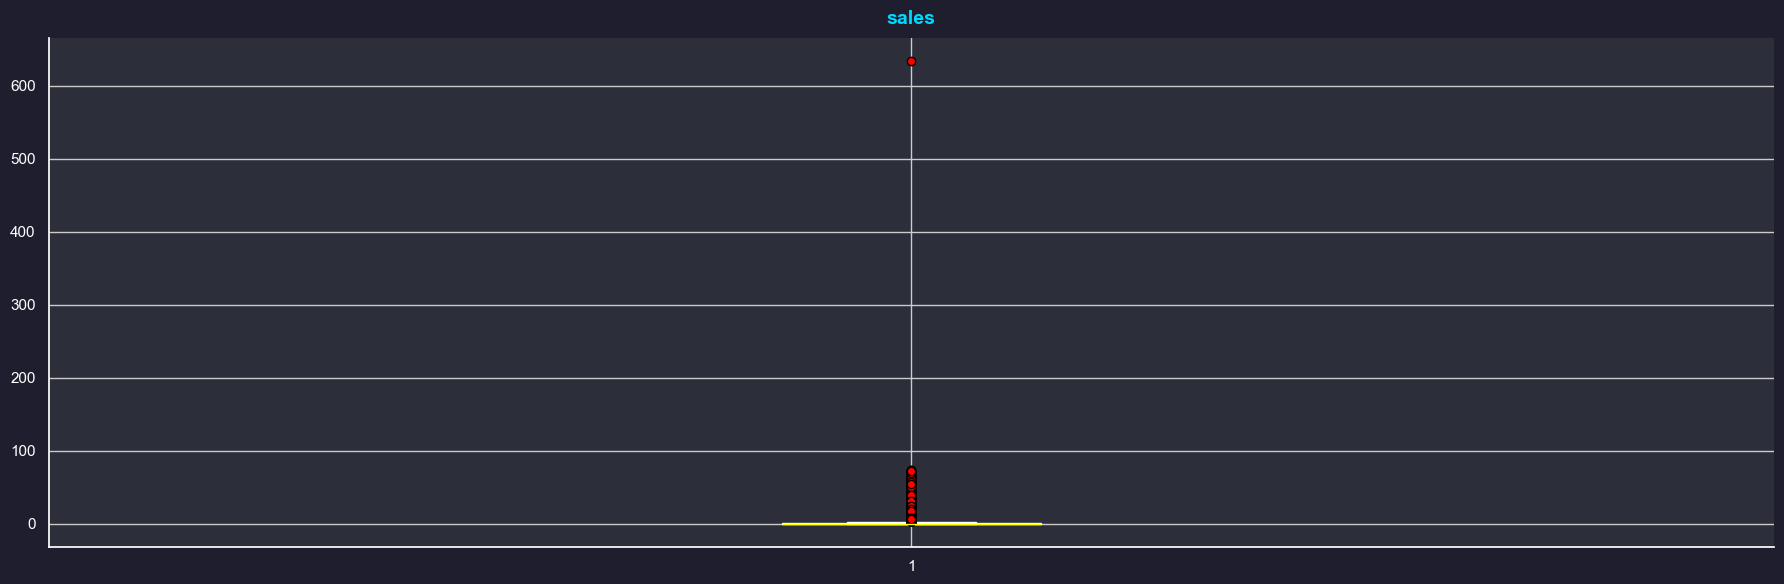

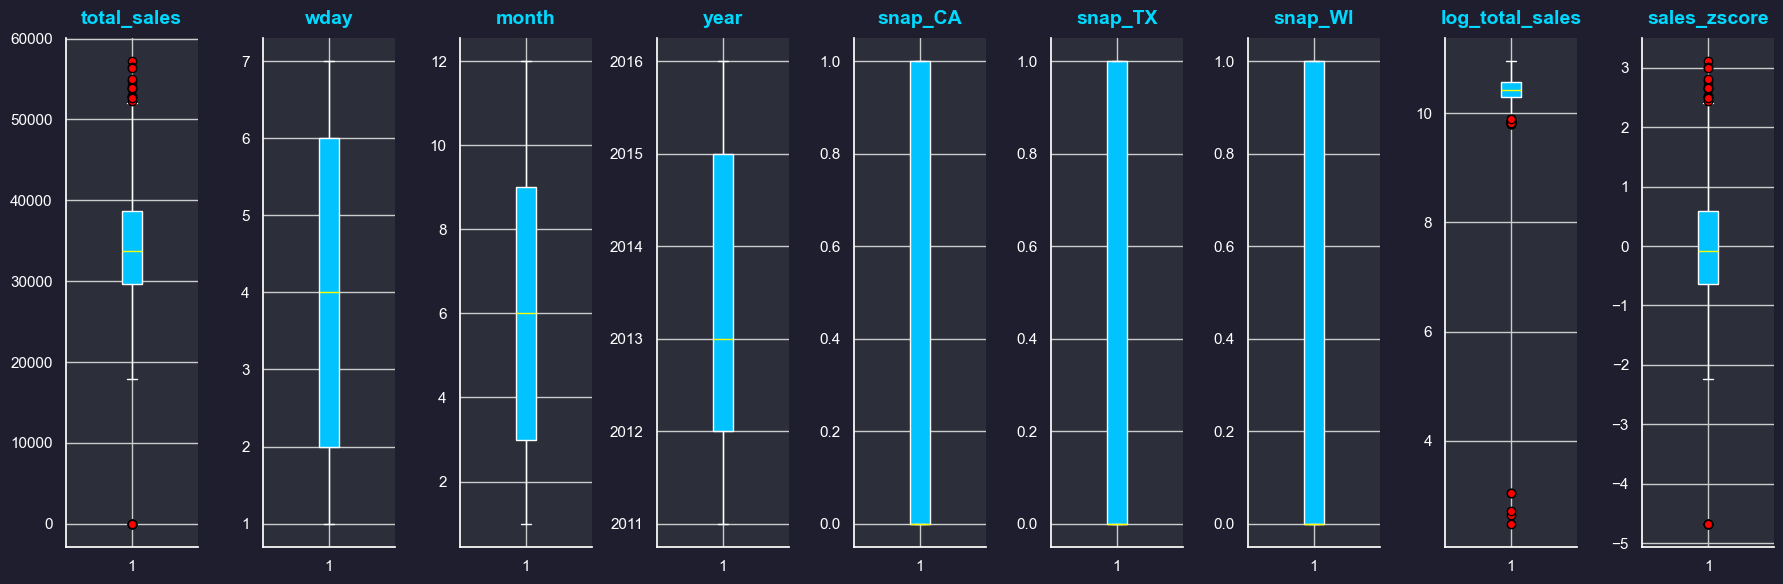

In [121]:
Data1 = [item_eda, eda_diario]

for df_idx, df in enumerate(Data1, start=1):
    columnas_numericas = df.select_dtypes(include=['int', 'float']).columns
    
    if len(columnas_numericas) == 0:
        continue
    
    fig, ax = plt.subplots(1, len(columnas_numericas), figsize=(18, 6))
    fig.patch.set_facecolor("#1e1e2f")


    if len(columnas_numericas) == 1:
        ax = [ax]

    for i, col in enumerate(columnas_numericas):
        ax[i].patch.set_facecolor("#2c2f3a")
        ax[i].boxplot(df[col], patch_artist=True,
                      boxprops=dict(facecolor='#00c3ff', color='white'),
                      capprops=dict(color='white'),
                      whiskerprops=dict(color='white'),
                      flierprops=dict(markerfacecolor='red', marker='o', markersize=6, linestyle='none'),
                      medianprops=dict(color='yellow'))
        
        ax[i].set_title(col, color='#00d9ff', fontsize=14, pad=10, weight='bold')
        ax[i].tick_params(colors='white', labelsize=11)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['bottom'].set_color('white')
        ax[i].spines['left'].set_color('white')

    plt.tight_layout()
    plt.show()



In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_dashboard_normalidad(df):
    # Seleccionar solo las columnas numéricas
    cols = df.select_dtypes(include=[np.number]).columns
    if len(cols) == 0:
        print("No hay columnas numéricas para graficar.")
        return
    
    # Configurar la cuadrícula (2 columnas, filas automáticas)
    cols_per_row = 2
    rows = int(np.ceil(len(cols) / cols_per_row))
    
    # Crear la figura con fondo negro
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, 3.5 * rows))
    fig.patch.set_facecolor('#0a0a0a') # Fondo oscuro principal
    
    # Aplanar los ejes para iterar fácilmente (por si hay más de 1 fila)
    if len(cols) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(cols):
        ax = axes[i]
        # Color de fondo de la tarjeta
        ax.set_facecolor('#141414') 
        
        # Obtener datos limpios
        data = df[col].dropna()
        if len(data) == 0:
            continue
            
        # Calcular Asimetría (Skew) y Curtosis (Kurt)
        s_val = data.skew()
        k_val = data.kurtosis()
        
        # Lógica para determinar el color y el porcentaje de normalidad
        abs_s = abs(s_val)
        
        # Fórmula heurística para acercarnos al porcentaje de tu imagen
        norm_pct = max(0.0, 100.0 - (abs_s * 34)) 
        
        if abs_s < 0.5:
            color = '#00ff00' # Verde neón
            status = 'Altamente normal'
        elif abs_s < 1.0:
            color = '#ffee00' # Amarillo neón
            status = 'Moderadamente sesgado'
        else:
            color = '#ff0033' # Rojo neón
            status = 'Altamente sesgado'
            if abs_s > 3: norm_pct = 0.0 # Si es muy asimétrico, cae a 0%
            
        # --- DIBUJAR TEXTOS ---
        # Título de la columna y Estado
        ax.text(0.05, 0.85, col.upper(), color='white', fontsize=11, fontweight='bold', transform=ax.transAxes)
        ax.text(0.95, 0.85, status, color=color, fontsize=10, ha='right', transform=ax.transAxes)
        
        # --- DIBUJAR BARRA DE PROGRESO ---
        # Barra gris de fondo
        ax.plot([0.05, 0.95], [0.72, 0.72], color='#333333', lw=4, transform=ax.transAxes, solid_capstyle='round')
        # Barra de color encima (largo basado en el porcentaje)
        largo_barra = 0.05 + 0.90 * (norm_pct / 100)
        if norm_pct > 0:
            ax.plot([0.05, largo_barra], [0.72, 0.72], color=color, lw=4, transform=ax.transAxes, solid_capstyle='round')
        
        # --- TEXTOS INFERIORES ---
        # Porcentaje
        ax.text(0.05, 0.40, f"{norm_pct:.1f}%", color=color, fontsize=20, fontweight='bold', transform=ax.transAxes)
        ax.text(0.05, 0.25, "NORMALIDAD", color='#555555', fontsize=8, fontweight='bold', transform=ax.transAxes)
        
        # Skew y Kurt
        ax.text(0.95, 0.48, f"SKW: {s_val:.2f}", color='#aaaaaa', fontsize=9, ha='right', transform=ax.transAxes)
        ax.text(0.95, 0.33, f"KUR: {k_val:.2f}", color='#aaaaaa', fontsize=9, ha='right', transform=ax.transAxes)
        
        # --- MINI GRÁFICO DE DENSIDAD (Sparkline) ---
        # Creamos un pequeño eje flotante en el centro-abajo de la tarjeta
        ax_inset = ax.inset_axes([0.45, 0.1, 0.3, 0.45])
        ax_inset.axis('off') # Ocultar bordes del mini gráfico
        
        # Evitar errores si la columna tiene un solo valor repetido (ej. ceros)
        if data.nunique() > 1:
            sns.kdeplot(data, ax=ax_inset, color=color, fill=True, alpha=0.5, linewidth=2)
        else:
            # Si todos los valores son iguales, dibujar una línea plana
            ax_inset.plot([0, 1], [0, 0], color=color, lw=2)
            
        # Limpiar los bordes y ejes de la tarjeta principal
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#222222') # Borde gris muy oscuro
            spine.set_linewidth(1.5)
            
    # Ocultar tarjetas vacías si el número de columnas es impar
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout(pad=3.0)
    plt.show()

# --- CÓMO USARLO ---
# Solo llama a la función pasándole tu tabla. Por ejemplo:

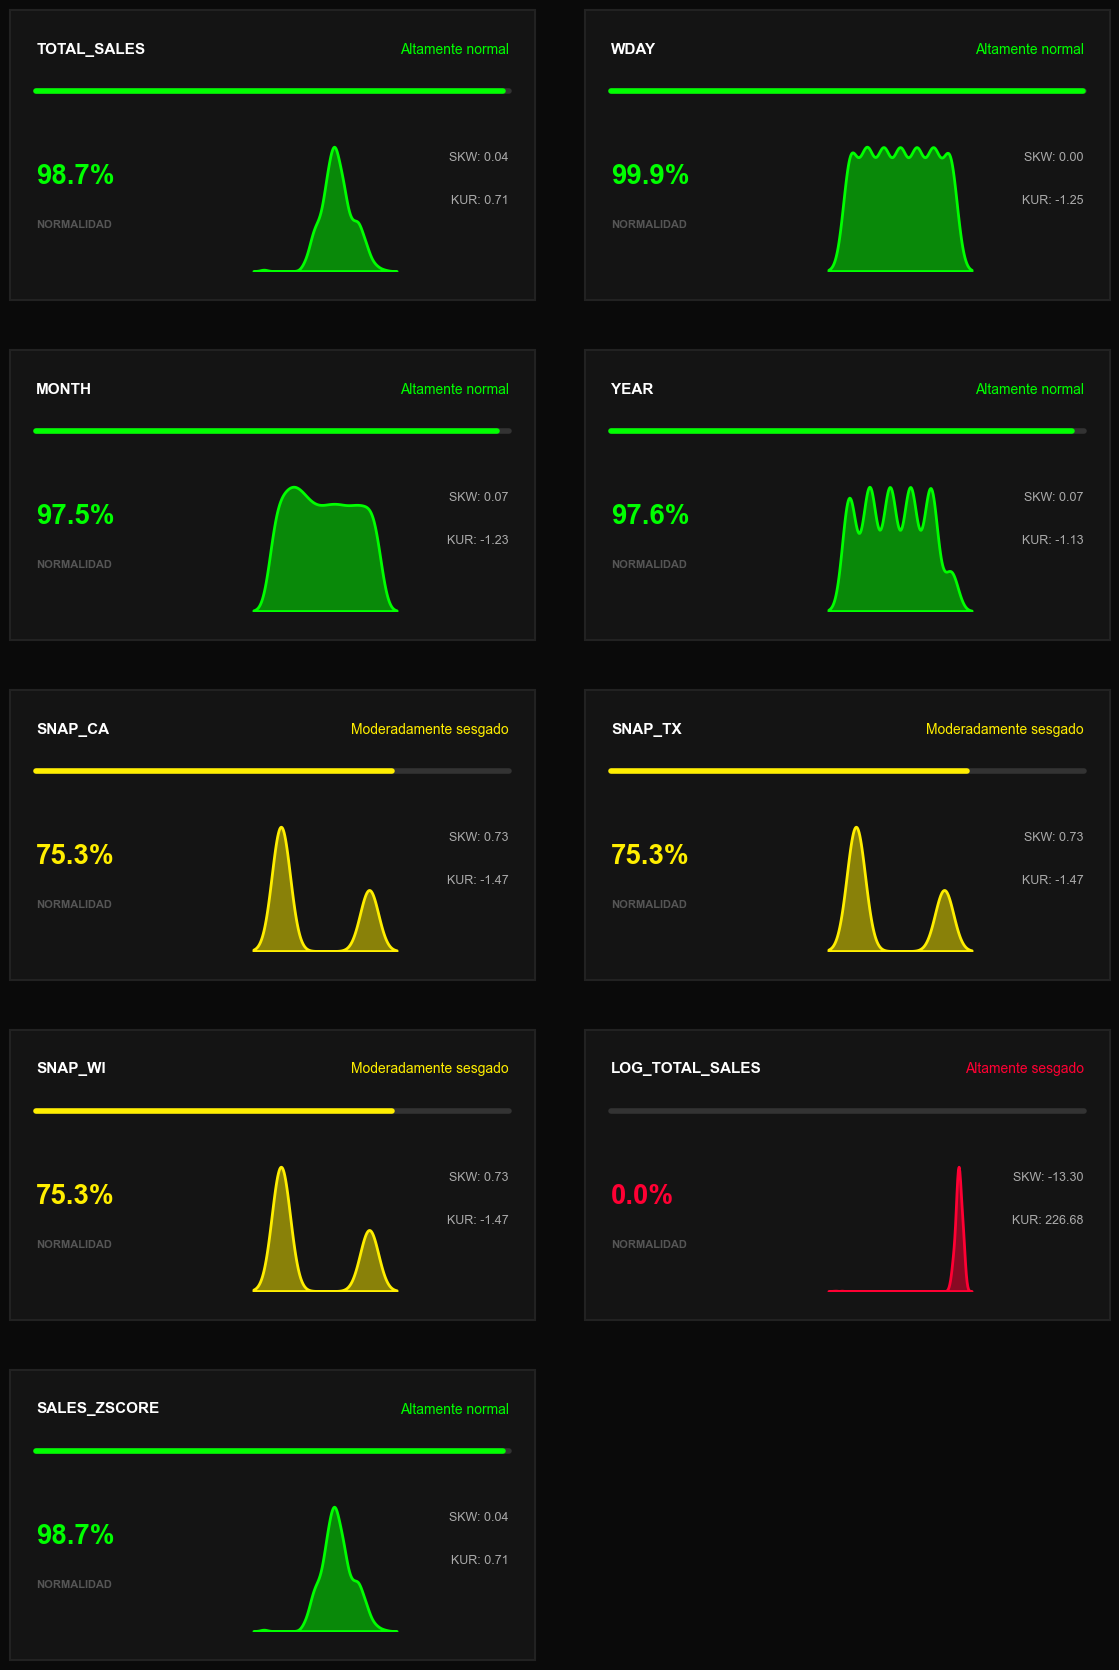

In [123]:
graficar_dashboard_normalidad(eda_diario)

In [124]:
#graficar_dashboard_normalidad(store_dept_eda)

In [125]:
#item_eda["LOG_SALES"] = np.log1p(item_eda["sales"]) 

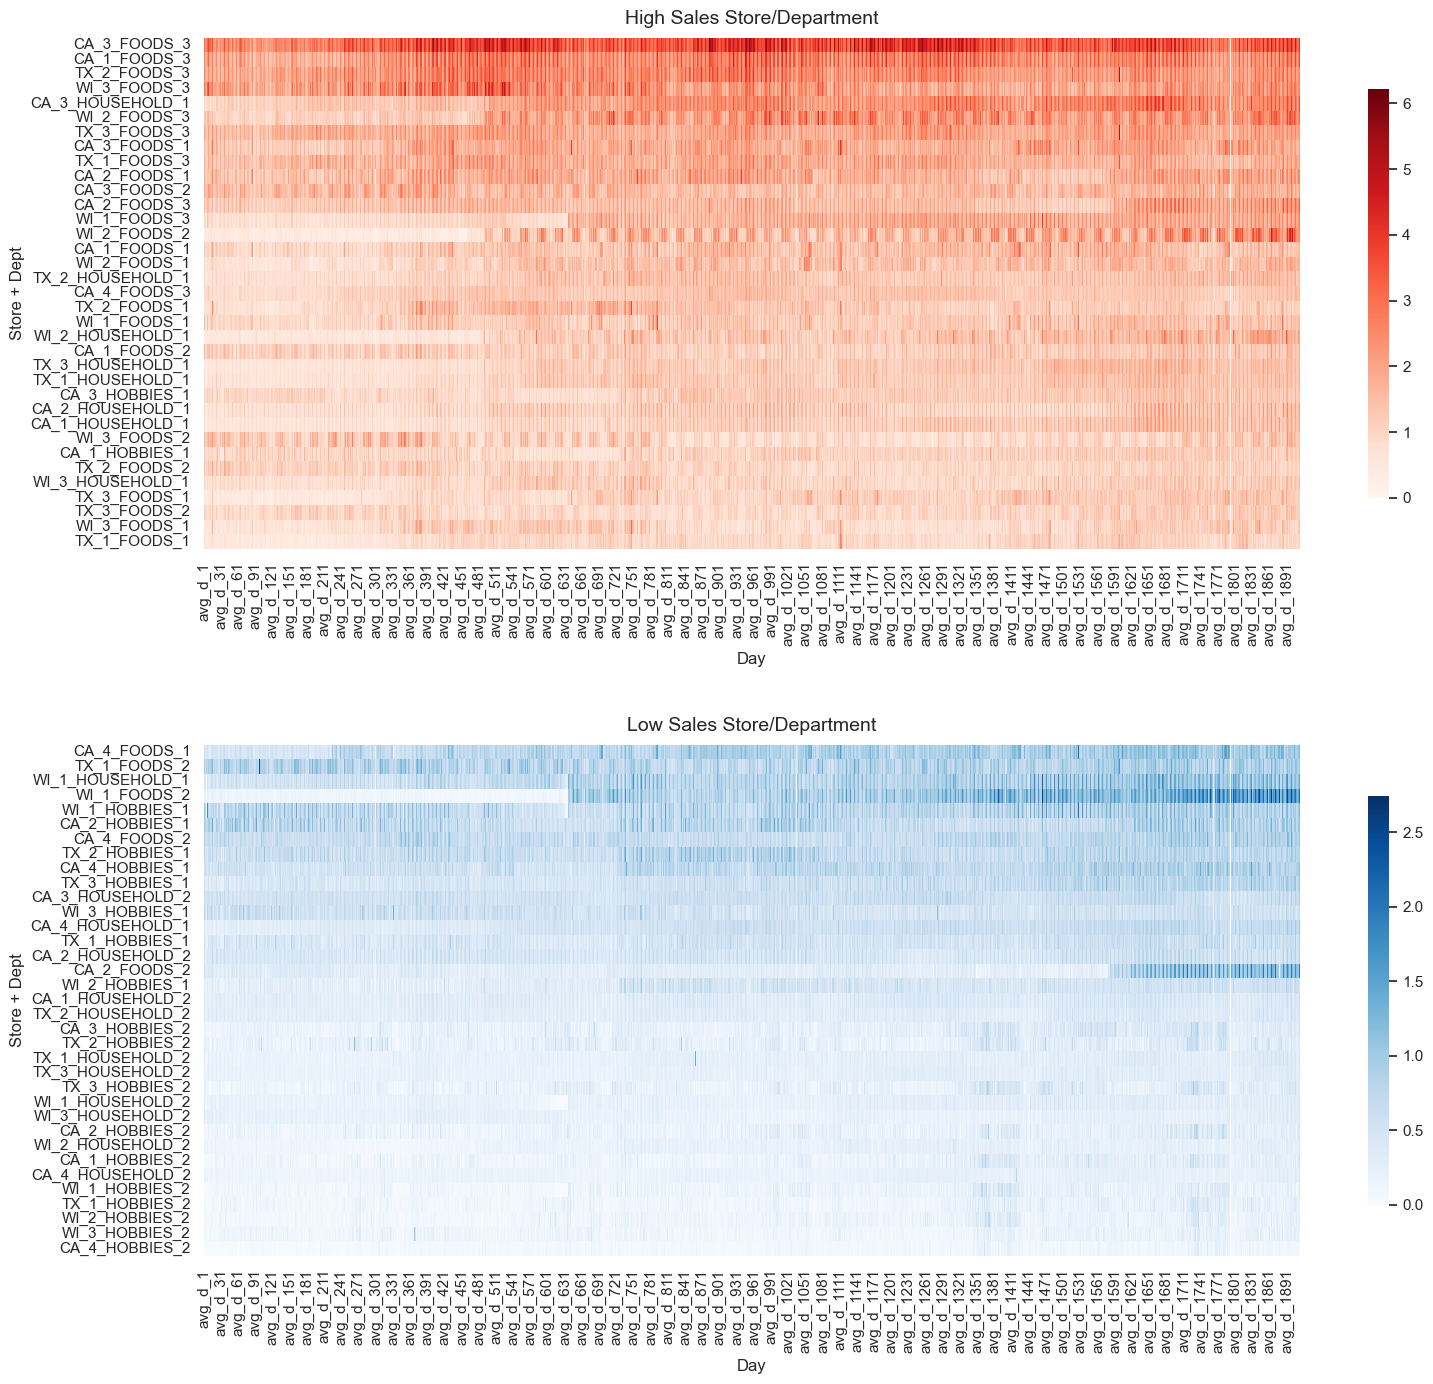

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparar los datos
# Hacemos una copia para no alterar tu tabla original
df_hm = store_dept_eda.copy()

# Crear una nueva columna combinando Store y Dept (ej. CA_1_FOODS_1) para el eje Y
df_hm['Store_Dept'] = df_hm['store_id'] + '_' + df_hm['dept_id']

# Establecer esta nueva columna como el índice (los nombres de las filas)
df_hm.set_index('Store_Dept', inplace=True)

# Seleccionar solo las columnas numéricas de los días (avg_d_1, avg_d_2...)
dia_cols = [c for c in df_hm.columns if c.startswith('avg_d_')]
df_hm = df_hm[dia_cols]

# 2. Separar en Ventas Altas y Bajas
# Calculamos el promedio general de cada fila para saber cuáles venden más
promedios_generales = df_hm.mean(axis=1)

# Ordenamos la tabla de mayor a menor venta
df_hm_ordenado = df_hm.loc[promedios_generales.sort_values(ascending=False).index]

# Dividimos la tabla a la mitad (o puedes ajustar el número si quieres ver menos filas)
mitad = len(df_hm_ordenado) // 2
high_sales = df_hm_ordenado.iloc[:mitad]
low_sales = df_hm_ordenado.iloc[mitad:]

# 3. Configurar y Dibujar los Gráficos
# Crear una figura con 2 filas y 1 columna
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 14))

# Frecuencia de las etiquetas del eje X (mostrar 1 de cada 30 días para que sea legible)
salto_dias = 30 

# --- Gráfico 1: Ventas Altas (Rojo) ---
sns.heatmap(high_sales, cmap="Reds", ax=axes[0], 
            xticklabels=salto_dias, yticklabels=True, 
            cbar_kws={'shrink': 0.8}) # shrink hace que la barra de color lateral sea un poco más estética
axes[0].set_title("High Sales Store/Department", fontsize=14, pad=10)
axes[0].set_ylabel("Store + Dept", fontsize=12)
axes[0].set_xlabel("Day", fontsize=12)
# Rotar las etiquetas X para que se lean bien
axes[0].tick_params(axis='x', rotation=90) 

# --- Gráfico 2: Ventas Bajas (Azul) ---
sns.heatmap(low_sales, cmap="Blues", ax=axes[1], 
            xticklabels=salto_dias, yticklabels=True, 
            cbar_kws={'shrink': 0.8})
axes[1].set_title("Low Sales Store/Department", fontsize=14, pad=10)
axes[1].set_ylabel("Store + Dept", fontsize=12)
axes[1].set_xlabel("Day", fontsize=12)
axes[1].tick_params(axis='x', rotation=90)

# Ajustar el espacio entre los dos gráficos para que no se choquen los textos
plt.tight_layout(h_pad=3.0)
plt.show()

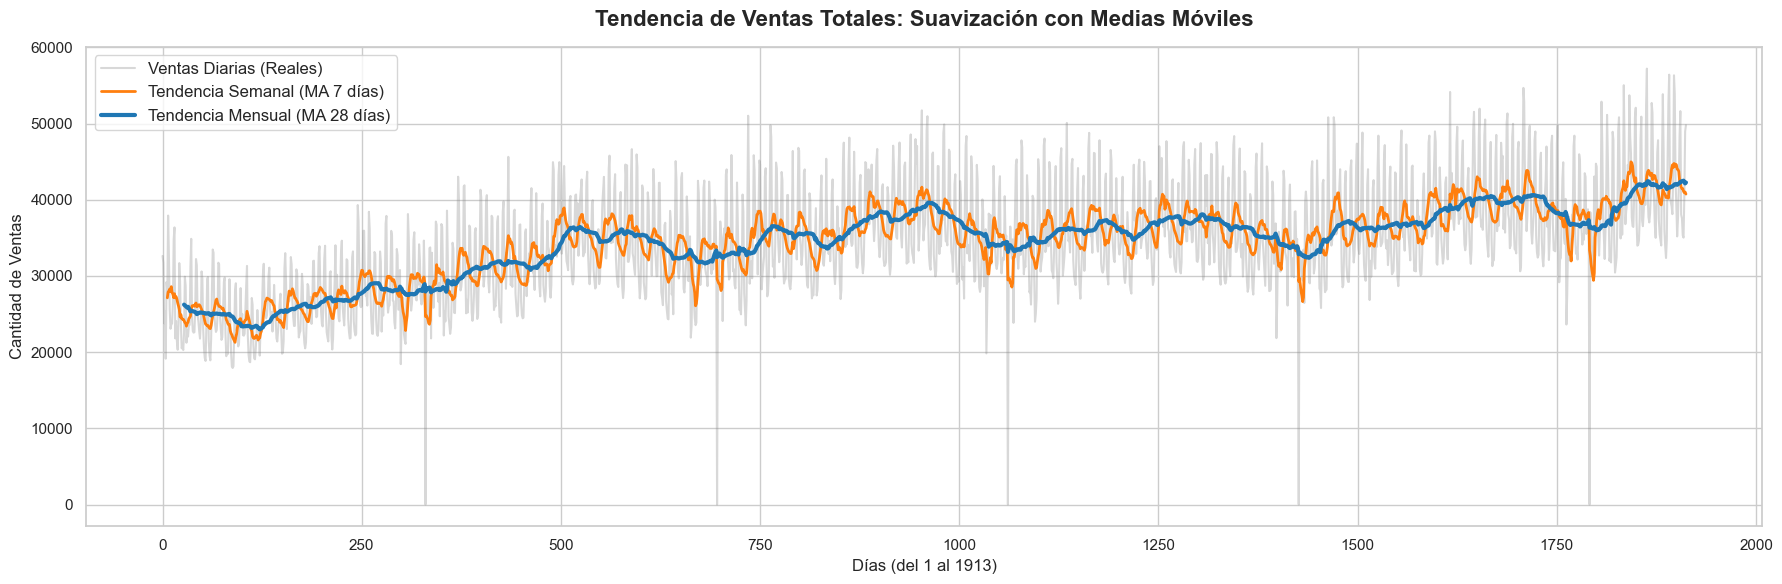

In [127]:
# 1. Hacemos una copia para no afectar tus datos originales
df_tendencia = eda_diario.copy()

# 2. Calcular las Medias Móviles usando la función .rolling() de Pandas
# window=7 significa que toma los 7 días anteriores y saca el promedio
df_tendencia['MA_7'] = df_tendencia['total_sales'].rolling(window=7).mean()
df_tendencia['MA_28'] = df_tendencia['total_sales'].rolling(window=28).mean()

# 3. Crear el gráfico
plt.figure(figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Graficar las ventas reales (en gris clarito porque hacen mucho ruido visual)
plt.plot(df_tendencia.index, df_tendencia['total_sales'], 
         label='Ventas Diarias (Reales)', color='gray', alpha=0.3)

# Graficar la Media Móvil de 7 días (Naranja)
plt.plot(df_tendencia.index, df_tendencia['MA_7'], 
         label='Tendencia Semanal (MA 7 días)', color='#ff7f0e', linewidth=2)

# Graficar la Media Móvil de 28 días (Azul oscuro - Tendencia a largo plazo)
plt.plot(df_tendencia.index, df_tendencia['MA_28'], 
         label='Tendencia Mensual (MA 28 días)', color='#1f77b4', linewidth=3)

# 4. Estética del gráfico
plt.title('Tendencia de Ventas Totales: Suavización con Medias Móviles', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Días (del 1 al 1913)', fontsize=12)
plt.ylabel('Cantidad de Ventas', fontsize=12)
plt.legend(fontsize=12, loc='upper left')

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

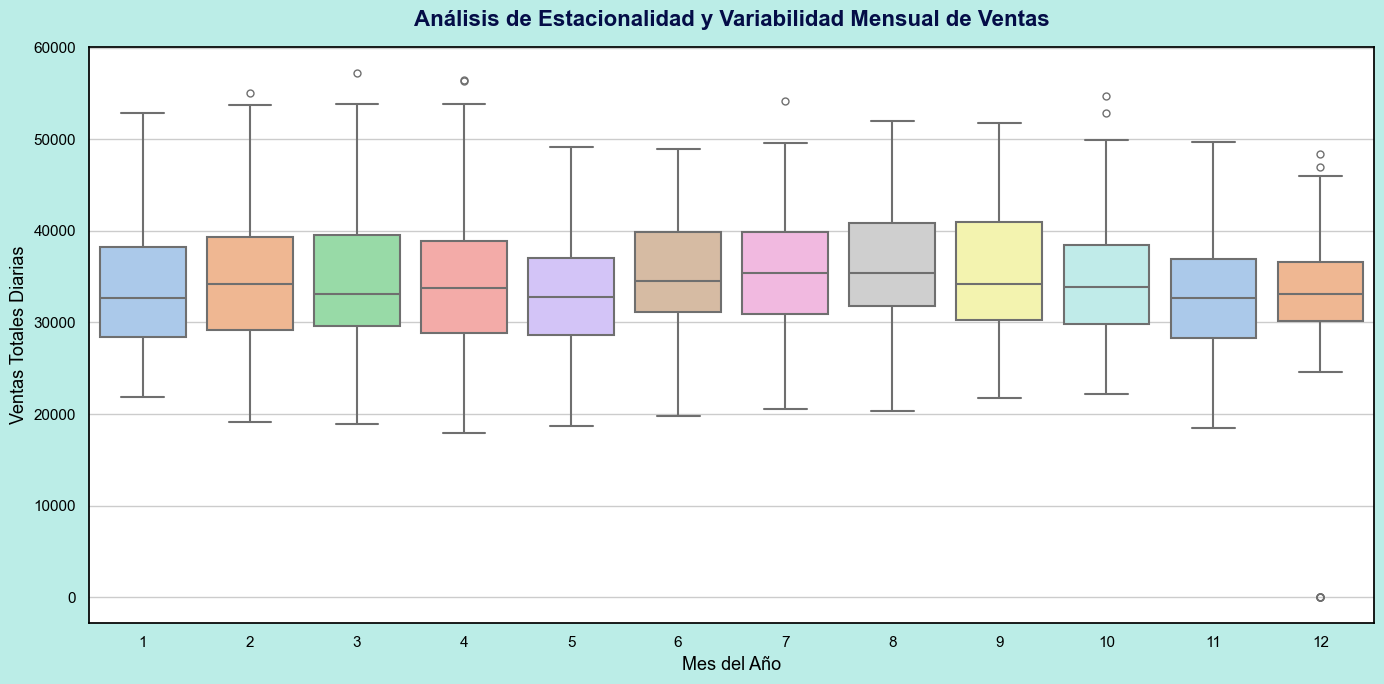

In [128]:
# 1. Configurar la figura y los colores de fondo
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#bbede7') 
ax.set_facecolor('#ffffff')

# 2. Crear el Boxplot de Estacionalidad Mensual
sns.boxplot(data=eda_diario, x='month', y='total_sales', 
            hue='month', legend=False, palette='pastel', ax=ax, 
            linewidth=1.5, fliersize=5)

# 3. Estética de los textos y ejes
plt.title('Análisis de Estacionalidad y Variabilidad Mensual de Ventas', color='#040d47', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mes del Año', color='black', fontsize=13)
plt.ylabel('Ventas Totales Diarias', color='#000000', fontsize=13)

ax.tick_params(axis='x', colors='black', labelsize=11) 
ax.tick_params(axis='y', colors='black', labelsize=11) 

for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

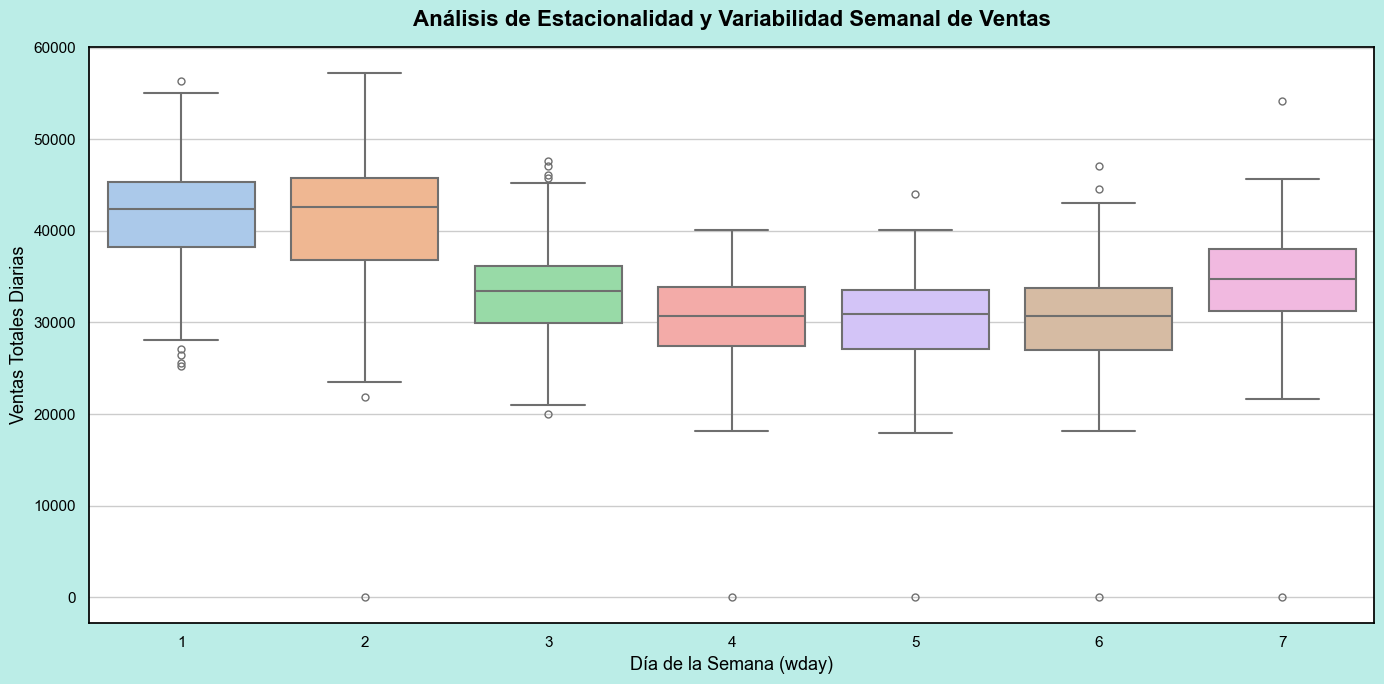

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar la figura y los colores de fondo
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#bbede7') 
ax.set_facecolor('#ffffff')

# 2. Crear el Boxplot de Estacionalidad Semanal
sns.boxplot(data=eda_diario, x='wday', y='total_sales', 
            hue='wday', legend=False, palette='pastel', ax=ax, 
            linewidth=1.5, fliersize=5)

# 3. Estética de los textos y ejes
plt.title('Análisis de Estacionalidad y Variabilidad Semanal de Ventas', color='black', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana (wday)', color='black', fontsize=13)
plt.ylabel('Ventas Totales Diarias', color='black', fontsize=13)

# Colores de los números en los ejes
ax.tick_params(axis='x', colors='black', labelsize=11) 
ax.tick_params(axis='y', colors='black', labelsize=11) 

# Borde interior
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import gc
import os

os.makedirs('data', exist_ok=True)


In [2]:


day_cols = pd.read_csv('sales_train_evaluation.csv', nrows=0).filter(regex='^d_').columns.tolist()
id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

dtype_map = {col: pl.Int16 for col in day_cols}

sales    = pl.read_csv('sales_train_evaluation.csv', schema_overrides=dtype_map)
calendar = pl.read_csv('calendar.csv')
prices   = pl.read_csv('sell_prices.csv', schema_overrides={'sell_price': pl.Float32})

print(f"Ventas: {sales.shape} | Calendario: {calendar.shape} | Precios: {prices.shape}")

Ventas: (30490, 1947) | Calendario: (1969, 14) | Precios: (6841121, 4)


In [3]:
tiendas = sales['store_id'].unique().to_list()
print(f"Tiendas: {tiendas}")

archivos_train = []
archivos_val   = []

for tienda in tiendas:
    print(f"Procesando {tienda}...")

    subset = sales.filter(pl.col('store_id') == tienda)

    # Melt con Polars (unpivot)
    df_t = subset.unpivot(
        on=day_cols,
        index=id_cols,
        variable_name='d',
        value_name='ventas'
    )

    df_t = df_t.with_columns(
        pl.col('d').str.replace('d_', '').cast(pl.Int16).alias('d_num')
    ).sort(['id', 'd_num'])

    # Merge calendario
    cal_cols = ['d', 'wm_yr_wk', 'wday', 'month', 'year',
                'event_name_1', 'event_type_1',
                'snap_CA', 'snap_TX', 'snap_WI']
    df_t = df_t.join(calendar.select(cal_cols), on='d', how='left')

    # Merge precios
    df_t = df_t.join(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

    # SNAP por estado
    df_t = df_t.with_columns(
        pl.when(pl.col('state_id') == 'CA').then(pl.col('snap_CA'))
          .when(pl.col('state_id') == 'TX').then(pl.col('snap_TX'))
          .otherwise(pl.col('snap_WI')).alias('snap')
    ).drop(['snap_CA', 'snap_TX', 'snap_WI'])

    # Convertir a pandas para calcular lags y medias móviles
    df_pd = df_t.to_pandas()
    del df_t
    gc.collect()

    grp = df_pd.groupby('id')['ventas']

    df_pd['lag_7']  = grp.shift(7)
    df_pd['lag_21'] = grp.shift(21)
    df_pd['lag_28'] = grp.shift(28)
    df_pd['lag_60'] = grp.shift(60)

    df_pd['ma_7']  = grp.shift(1).groupby(df_pd['id']).transform(lambda x: x.rolling(7,  min_periods=1).mean())
    df_pd['ma_21'] = grp.shift(1).groupby(df_pd['id']).transform(lambda x: x.rolling(21, min_periods=1).mean())
    df_pd['ma_28'] = grp.shift(1).groupby(df_pd['id']).transform(lambda x: x.rolling(28, min_periods=1).mean())
    df_pd['ma_60'] = grp.shift(1).groupby(df_pd['id']).transform(lambda x: x.rolling(60, min_periods=1).mean())

    df_pd['std_7']  = grp.shift(1).groupby(df_pd['id']).transform(lambda x: x.rolling(7,  min_periods=1).std())
    df_pd['std_28'] = grp.shift(1).groupby(df_pd['id']).transform(lambda x: x.rolling(28, min_periods=1).std())

    float_cols = ['lag_7','lag_21','lag_28','lag_60','ma_7','ma_21','ma_28','ma_60','std_7','std_28']
    df_pd[float_cols] = df_pd[float_cols].astype('float32')

    # Split y exportar
    train_path = f'data/train_{tienda}.parquet'
    val_path   = f'data/val_{tienda}.parquet'

    df_pd[df_pd['d_num'] <= 1913].to_parquet(train_path, index=False)
    df_pd[df_pd['d_num'] >  1913].to_parquet(val_path,   index=False)

    archivos_train.append(train_path)
    archivos_val.append(val_path)

    del df_pd, grp, subset
    gc.collect()
    print(f"   {tienda} listo")

# Unir todos
print("Uniendo archivos finales...")
pd.concat([pd.read_parquet(f) for f in archivos_train]).to_parquet('m5_train.parquet', index=False)
pd.concat([pd.read_parquet(f) for f in archivos_val]).to_parquet('m5_val.parquet',     index=False)

print(" m5_train.parquet")
print(" m5_val.parquet")

Tiendas: ['CA_4', 'CA_3', 'TX_2', 'TX_1', 'CA_2', 'WI_1', 'WI_2', 'WI_3', 'CA_1', 'TX_3']
Procesando CA_4...
   CA_4 listo
Procesando CA_3...
   CA_3 listo
Procesando TX_2...
   TX_2 listo
Procesando TX_1...
   TX_1 listo
Procesando CA_2...
   CA_2 listo
Procesando WI_1...
   WI_1 listo
Procesando WI_2...
   WI_2 listo
Procesando WI_3...
   WI_3 listo
Procesando CA_1...
   CA_1 listo
Procesando TX_3...
   TX_3 listo
Uniendo archivos finales...
 m5_train.parquet
 m5_val.parquet
